In [1]:
# Block 1 — Import & Setup
import math
import random
import matplotlib.pyplot as plt
import hashlib
import gc

In [2]:
# Block 2 - Dynamic Factors (mock data)
dynamic_factors = {
    "wind_speed": 23.4,
    "storm_index": 41.8,
    "star_index": 8.2,
    "humidity": 67.5,
    "tide_level": 52.1
}

In [3]:
# BLOCK 3 — Normalize into 2-digit
def normalize_to_2_digits(value, min_value, max_value):
    value = max(min_value, min(value, max_value))
    scaled = int((value - min_value) / (max_value - min_value) * 99)
    return f"{scaled:02d}"

In [4]:
# BLOCK 4 — Generate Dynamic Code (10 digits)
def generate_dynamic_code(dynamic_factors, user_id, timestamp):
    # Tạo secret salt riêng cho từng user/session
    salt = hashlib.sha256(
        f"{user_id}:{timestamp}".encode()
    ).hexdigest()[:8]

    a = normalize_to_2_digits(dynamic_factors["wind_speed"], 0, 50)
    b = normalize_to_2_digits(dynamic_factors["storm_index"], 0, 100)
    c = normalize_to_2_digits(dynamic_factors["star_index"], 0, 20)
    d = normalize_to_2_digits(dynamic_factors["humidity"], 0, 100)
    e = normalize_to_2_digits(dynamic_factors["tide_level"], 0, 100)

    raw_code = f"{a}{b}{c}{d}{e}"

    # XOR code với salt để scramble
    scrambled = ""
    for i, ch in enumerate(raw_code):
        scrambled += str((int(ch) + int(salt[i % len(salt)], 16)) % 10)

    return scrambled  # code này không lưu lại

In [5]:
# BLOCK 5 — Decode Code to parameters
def decode_code(code):
    blocks = [int(code[i:i+2]) for i in range(0, 10, 2)]
    params = {
        "intensity": max(80, blocks[0] * 2),
        "direction_bias": blocks[1],
        "waypoint_density": max(2, (blocks[2] % 4) + 2),
        "noise_strength": max(0.8, blocks[3] / 50.0),
        "smooth_factor": blocks[4] / 100.0
    }
    return params

In [6]:
# BLOCK 6 — Interpolation helper
def interpolate(p1, p2, ratio):
    x = p1[0] + (p2[0] - p1[0]) * ratio
    y = p1[1] + (p2[1] - p1[1]) * ratio
    return (x, y)

In [7]:
# BLOCK 7 — Inject Waypoints (core distortion)
METERS_PER_DEGREE = 111_000

def inject_waypoints(trajectory, waypoint_density, intensity):
    new_traj = []
    offset_scale = (intensity * 3) / METERS_PER_DEGREE

    for i in range(len(trajectory) - 1):
        p1 = trajectory[i]
        p2 = trajectory[i + 1]
        new_traj.append(p1)

        for j in range(1, waypoint_density + 1):
            ratio = j / (waypoint_density + 1)
            mid = interpolate(p1, p2, ratio)

            offset_x = random.uniform(-offset_scale, offset_scale)
            offset_y = random.uniform(-offset_scale, offset_scale)

            new_traj.append((mid[0] + offset_x, mid[1] + offset_y))

    new_traj.append(trajectory[-1])
    return new_traj

def apply_noise(trajectory, noise_strength, direction_bias,
                preserve_endpoints=True):
    biased_angle = (direction_bias / 99.0) * 2 * math.pi
    result = []

    for i, (x, y) in enumerate(trajectory):
        if preserve_endpoints and (i == 0 or i == len(trajectory) - 1):
            result.append((x, y))
            continue

        max_offset = (noise_strength * 180) / METERS_PER_DEGREE

        dx = math.cos(biased_angle) * random.uniform(-max_offset, max_offset)
        dy = math.sin(biased_angle) * random.uniform(-max_offset, max_offset)

        dx += random.uniform(-max_offset, max_offset)
        dy += random.uniform(-max_offset, max_offset)

        result.append((x + dx, y + dy))

    return result

In [8]:
# BLOCK 8 — Apply Noise + Direction Bias
def validate_fake_trajectory(real_trajectory, fake_trajectory,
                              max_distance_meters=350):
    max_dist_deg = max_distance_meters / METERS_PER_DEGREE

    for (rx, ry), (fx, fy) in zip(real_trajectory,
                                   fake_trajectory[:len(real_trajectory)]):
        dist = math.sqrt((rx - fx)**2 + (ry - fy)**2)
        if dist > max_dist_deg:
            return False
    return True

def generate_fake_trajectory(real_trajectory, dynamic_factors,
                              user_id, timestamp, max_retries=5):
    code = generate_dynamic_code(dynamic_factors, user_id, timestamp)
    params = decode_code(code)

    fake = None
    for attempt in range(max_retries):
        candidate = inject_waypoints(real_trajectory,
                                     params["waypoint_density"],
                                     params["intensity"])
        candidate = apply_noise(candidate,
                                params["noise_strength"],
                                params["direction_bias"])
        candidate = smooth_trajectory(candidate)

        if validate_fake_trajectory(real_trajectory, candidate):
            fake = candidate
            break

        params["intensity"] = int(params["intensity"] * 0.7)
        params["noise_strength"] *= 0.7

    if fake is None:
        fake = smooth_trajectory(real_trajectory)  # fallback an toàn

    code = None
    secure_clear_dict(params)
    params = None
    gc.collect()

    return fake

In [9]:
# BLOCK 9 — Smooth Trajectory
def smooth_trajectory(trajectory):
    if len(trajectory) < 3:
        return trajectory

    smoothed = [trajectory[0]]

    for i in range(1, len(trajectory) - 1):
        x = (trajectory[i - 1][0] + trajectory[i][0] + trajectory[i + 1][0]) / 3
        y = (trajectory[i - 1][1] + trajectory[i][1] + trajectory[i + 1][1]) / 3
        smoothed.append((x, y))

    smoothed.append(trajectory[-1])
    return smoothed

In [10]:
# BLOCK 10 - Secure Cleanup
def secure_clear_dict(d):
    if isinstance(d, dict):
        for key in list(d.keys()):
            d[key] = None
        d.clear()

In [11]:
# BLOCK 11 — Plot
def plot_trajectories(real, fake):
    rx, ry = zip(*real)
    fx, fy = zip(*fake)

    plt.figure(figsize=(6,6))
    plt.plot(rx, ry, 'b-o', label='Real Trajectory')
    plt.plot(fx, fy, 'r-o', label='Fake Trajectory')
    plt.legend()
    plt.title("Trajectory Obfuscation")
    plt.show()

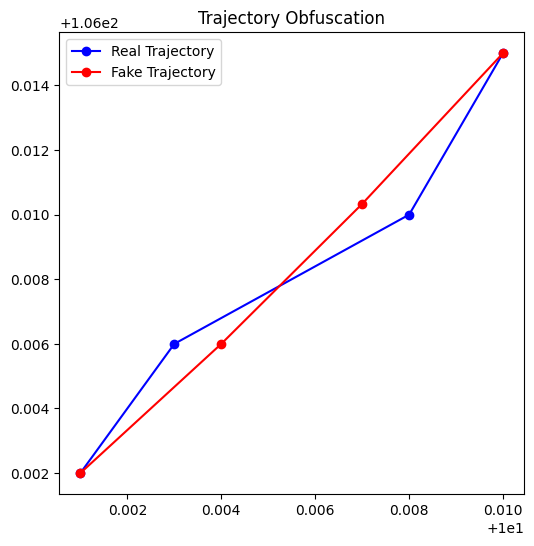

In [12]:
# BLOCK 12 — Run Demo
real_trajectory = [
    (10.001, 106.002),
    (10.003, 106.006),
    (10.008, 106.010),
    (10.010, 106.015)
]

fake_trajectory = generate_fake_trajectory(
    real_trajectory,
    dynamic_factors,
    user_id=123,
    timestamp=1700000000
)

plot_trajectories(real_trajectory, fake_trajectory)